<a href="https://colab.research.google.com/github/Rahdiani/Projectweb-Rahdiani/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
import re

In [2]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
reviews_df = pd.read_csv('20191002-reviews.csv')

In [4]:
reviews_df.head()

,itemId,category,name,rating,originalRating,reviewTitle,reviewContent,likeCount,upVotes,downVotes,helpful,relevanceScore,boughtDate,clientType,retrievedDate
0,100002528,beli-harddisk-eksternal,Kamal U.,5,NaN,NaN,bagus mantap dah sesui pesanan,0,0,0,True,26.51,09 Apr 2019,androidApp,2019-10-02
1,100002528,beli-harddisk-eksternal,yofanca m.,4,NaN,NaN,"Bagus, sesuai foto",0,0,0,True,22.49,24 Sep 2017,androidApp,2019-10-02
2,100002528,beli-harddisk-eksternal,Lazada Customer,5,NaN,ok mantaaapppp barang sesuai pesanan.. good,okkkkk mantaaaaaaapppp ... goood,0,0,0,True,21.50,04 Apr 2018,androidApp,2019-10-02
3,100002528,beli-harddisk-eksternal,Lazada Customer,4,NaN,NaN,bagus sesuai,0,0,0,True,20.51,22 Sep 2017,androidApp,2019-10-02
4,100002528,beli-harddisk-eksternal,Yosep M.,5,NaN,NaN,NaN,0,0,0,True,16.01,17 Agu 2018,androidApp,2019-10-02


In [5]:
reviews_df = reviews_df[['itemId', 'rating', 'reviewContent']]
reviews_df.dropna(subset=['reviewContent', 'rating'], inplace=True)

In [6]:
def label_kepuasan_rating(rating):
    if rating >= 4:
        return 'Puas'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Tidak Puas'

reviews_df['kepuasan_rating'] = reviews_df['rating'].apply(label_kepuasan_rating)

In [7]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()  # tokenizer sederhana (anti error)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

reviews_df['clean_review'] = reviews_df['reviewContent'].apply(preprocess_text)

In [8]:
reviews_df[['reviewContent', 'clean_review']].head()

,reviewContent,clean_review
0,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesanan
1,"Bagus, sesuai foto",bagus sesuai foto
2,okkkkk mantaaaaaaapppp ... goood,okkkkk mantaaaaaaapppp goood
3,bagus sesuai,bagus sesuai
7,bima,bima


In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def sentimen_nltk(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Puas'
    elif score <= -0.05:
        return 'Tidak Puas'
    else:
        return 'Netral'

reviews_df['kepuasan_nltk'] = reviews_df['clean_review'].apply(sentimen_nltk)

In [10]:
reviews_df['kepuasan_nltk'].value_counts()

,count
kepuasan_nltk,
Netral,78503
Puas,26283
Tidak Puas,2243


In [11]:
reviews_df['kepuasan_rating'].value_counts()

,count
kepuasan_rating,
Puas,93522
Tidak Puas,9135
Netral,4372


In [12]:
pd.crosstab(
    reviews_df['kepuasan_rating'],
    reviews_df['kepuasan_nltk'],
    rownames=['Rating'],
    colnames=['Sentimen NLTK']
)

Sentimen NLTK,Netral,Puas,Tidak Puas
Rating,,,
Netral,3401,867,104
Puas,67438,24479,1605
Tidak Puas,7664,937,534


<Axes: title={'center': 'Kepuasan Pelanggan Berdasarkan Review Lazada'}, xlabel='kepuasan_nltk'>

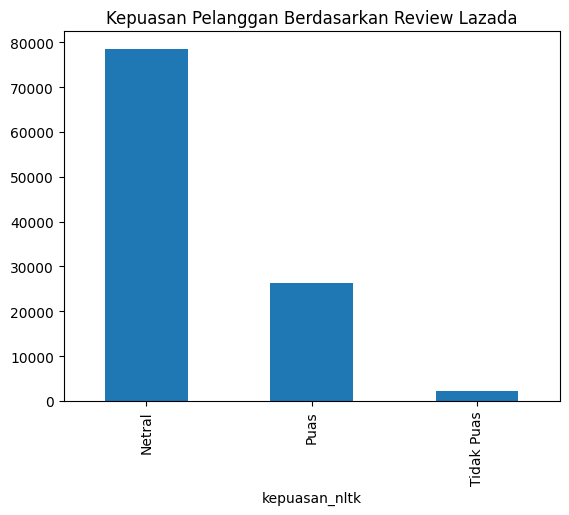

In [13]:
reviews_df['kepuasan_nltk'].value_counts().plot(
    kind='bar',
    title='Kepuasan Pelanggan Berdasarkan Review Lazada'
)